In [4]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
import itertools

In [5]:
# Index for each activity
activity_indices = {
  'Stationary': 0,
  'Walking-flat-surface': 1,
  'Walking-up-stairs': 2,
  'Walking-down-stairs': 3,
  'Elevator-up': 4,
  'Running': 5,
  'Elevator-down': 6
}

In [30]:
def compute_raw_data_robust(path, activity):
    accel_path = get_sensor_file(path, activity, 'accel')
    gyro_path = get_sensor_file(path, activity, 'gyro')
    pressure_path = get_sensor_file(path, activity, 'pressure')

    if not accel_path or not gyro_path:
        print(f"  [SKIP] {activity}: Missing sensor files.")
        return None, None

    accel_raw = pd.read_csv(accel_path, sep=",", names=['time', 'x', 'y', 'z'])
    gyro_raw = pd.read_csv(gyro_path, sep=",", names=['time', 'gx', 'gy', 'gz'])
    
    if not pressure_path:
        pressure_raw = pd.DataFrame({'time': accel_raw['time'], 'p': 1013.25})
    else:
        pressure_raw = pd.read_csv(pressure_path, sep=",", names=['time', 'p'])

    # --- AUTO-UNIT DETECTION ---
    t_min = max(accel_raw['time'].min(), pressure_raw['time'].min(), gyro_raw['time'].min())
    t_max = min(accel_raw['time'].max(), pressure_raw['time'].max(), gyro_raw['time'].max())
    total_duration = t_max - t_min

    # If duration > 1000, it's likely milliseconds. If < 1000, it's seconds.
    is_ms = total_duration > 1000
    
    # Set trim to 0.5 seconds and sampling step to 20ms (50Hz)
    trim = 500 if is_ms else 0.5
    step = 20 if is_ms else 0.02
    
    t_start = t_min + trim
    t_end = t_max - trim
    
    if t_end <= t_start:
        print(f"  [SKIP] {activity}: Duration ({total_duration}) too short for trim.")
        return None, None

    timestamps = np.arange(t_start, t_end, step) 
    # ---------------------------

    ax = np.interp(timestamps, accel_raw['time'], accel_raw['x'])
    ay = np.interp(timestamps, accel_raw['time'], accel_raw['y'])
    az = np.interp(timestamps, accel_raw['time'], accel_raw['z'])
    p = np.interp(timestamps, pressure_raw['time'], pressure_raw['p'])
    gx = np.interp(timestamps, gyro_raw['time'], gyro_raw['gx'])
    gy = np.interp(timestamps, gyro_raw['time'], gyro_raw['gy'])
    gz = np.interp(timestamps, gyro_raw['time'], gyro_raw['gz'])

    accel_mag = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)
    labels = np.full(len(timestamps), activity_indices[activity])

    return np.stack((accel_mag, p, gyro_mag), axis=1), labels

In [7]:
def plot_raw_data(raw_data_features, raw_data_labels):
  """ This function plots the raw data features (after applying basic data processing) and raw data labels.
      The first subplot is the the accelerometer magnitude. The second subplot is the barometric pressure.
      The third subplot is the activity label (check "activity_indices" to see what activity each index corresponds to).
  """
  accel_magnitudes = np.sqrt((raw_data_features[:, 0]**2).reshape(-1, 1)+
                             (raw_data_features[:, 1]**2).reshape(-1, 1)+
                             (raw_data_features[:, 2]**2).reshape(-1, 1))

  plt.subplot(3, 1, 1)
  plt.plot(accel_magnitudes)
  plt.xticks(fontsize=8)
  plt.ylabel('Acceleration (m/s^2)', fontsize=8)
  plt.yticks(fontsize=8)
  plt.gca().set_title('Accelerometer Magnitude', fontsize=8)

  plt.subplot(3, 1, 2)
  plt.plot(raw_data_features[:, 3])
  plt.xticks(fontsize=8)
  plt.ylabel('Pressure (mbar)', fontsize=8)
  plt.yticks(fontsize=8)
  plt.gca().set_title('Barometric Pressure', fontsize=8)

  plt.subplot(3, 1, 3)
  plt.plot(raw_data_labels)
  plt.xticks(fontsize=8)
  plt.yticks(fontsize=8)
  plt.ylabel('Activity', fontsize=8)
  plt.gca().set_title('Activity Label', fontsize=8)
  plt.grid(True)

  plt.show()

In [ ]:
def feature_extraction(raw_data_features, raw_data_labels, timestamps):
  """    raw_data_features: The fourth column is the barometer data.

  Returns:
    features: Features extracted from the data features, where
              features[:, 0] is the mean magnitude of acceleration;
              features[:, 1] is the variance of acceleration;
              features[:, 2:6] is the fft power spectrum of equally-spaced frequencies;
              features[: 6:12] is the fft power spectrum of frequencies in logarithmic sacle;
              features[:, 13] is the slope of pressure.
  Args:

  """
  features = None
  labels = None

  accel_magnitudes = np.sqrt((raw_data_features[:, 0]**2).reshape(-1, 1)+
                             (raw_data_features[:, 1]**2).reshape(-1, 1)+
                             (raw_data_features[:, 2]**2).reshape(-1, 1))

  # The window size for feature extraction
  segment_size = 128


  for i in range(0, accel_magnitudes.shape[0]-segment_size, 64):
    segment = accel_magnitudes[i:i+segment_size, :]
    accel_mean = np.mean(segment)
    accel_var = np.var(segment)

    segment_fft_powers = np.abs(np.fft.fft(segment))**2

    # Aggreate band power within frequency range, with equal space (window size=32) or logarithmic scale
    # Band power of equally-sapced bands
    equal_band_power = list()
    window_size = 32
    for j in range(0, len(segment_fft_powers), window_size):
      equal_band_power.append(sum(segment_fft_powers[j: j+32]).tolist()[0])

    # Band power of bands in logarithmic scale
    log_band_power = list()
    freqs = [0, 2, 4, 8, 16, 32, 64, 128]
    for j in range(len(freqs)-1):
      log_band_power.append(sum(segment_fft_powers[freqs[j]: freqs[j+1]]).tolist()[0])

    # Slope of barometer data
    # bar_slope = raw_data_features[i+segment_size-1, 3] - raw_data_features[i, 3]
    bar_slope = np.polyfit(timestamps[i:i+segment_size], raw_data_features[i:i+segment_size, 3], 1)[0]
    # bar_slope = np.polyfit([x*0.1 for x in range(segment_size)], raw_data_features[i:i+segment_size, 3], 1)[0]

    feature = [accel_mean, accel_var] + equal_band_power + log_band_power + [bar_slope]

    if features is None:
      features = np.array([feature])
    else:
      features = np.append(features, [feature], axis=0)

    label = Counter(raw_data_labels[i:i+segment_size][:, 0].tolist()).most_common(1)[0][0]

    if labels is None:
      labels = np.array([label])
    else:
      labels = np.append(labels, [label], axis=0)

  return features, labels

In [ ]:
import matplotlib.pyplot as plt

def plot_extracted_features(features, labels, index_accel=2, index_baro=-1):
  """ 
  Plots extracted features based on provided indices.
  index_accel: index for the top plot (default 2)
  index_baro: index for the middle plot (default -1)
  """
  #plt.figure(figsize=(10, 8)) # Added for better visibility

  # Plot the acceleration feature
  plt.subplot(3, 1, 1)
  plt.plot(features[:, index_accel])
  plt.xticks(fontsize=8)
  plt.yticks(fontsize=8)
  plt.ylabel('Value', fontsize=8)
  plt.gca().set_title(f'Feature at Index {index_accel} (Accelerometer)', fontsize=8)

  # Plot the barometer feature
  plt.subplot(3, 1, 2)
  plt.plot(features[:, index_baro])
  plt.xticks(fontsize=8)
  plt.yticks(fontsize=8)
  plt.ylabel('Value', fontsize=8)
  plt.gca().set_title(f'Feature at Index {index_baro} (Barometer)', fontsize=8)

  # Plot the activity label
  plt.subplot(3, 1, 3)
  plt.plot(labels, color='green') # Color helps distinguish labels
  plt.xticks(fontsize=8)
  plt.yticks(fontsize=8)
  plt.gca().set_title('Activity Label', fontsize=8)
  plt.grid(True)

  plt.tight_layout() # Prevents overlapping labels
  plt.show()

# Example usage:
plot_extracted_features(features, labels, index_accel=2, index_baro=-1)

TO DO 7

  [SUCCESS] Stationary: 120 windows.
  [SUCCESS] Walking-flat-surface: 129 windows.
  [SUCCESS] Walking-up-stairs: 89 windows.
  [SUCCESS] Walking-down-stairs: 29 windows.
  [SUCCESS] Running: 147 windows.
  [SUCCESS] Elevator-up: 24 windows.
  [SUCCESS] Elevator-down: 26 windows.


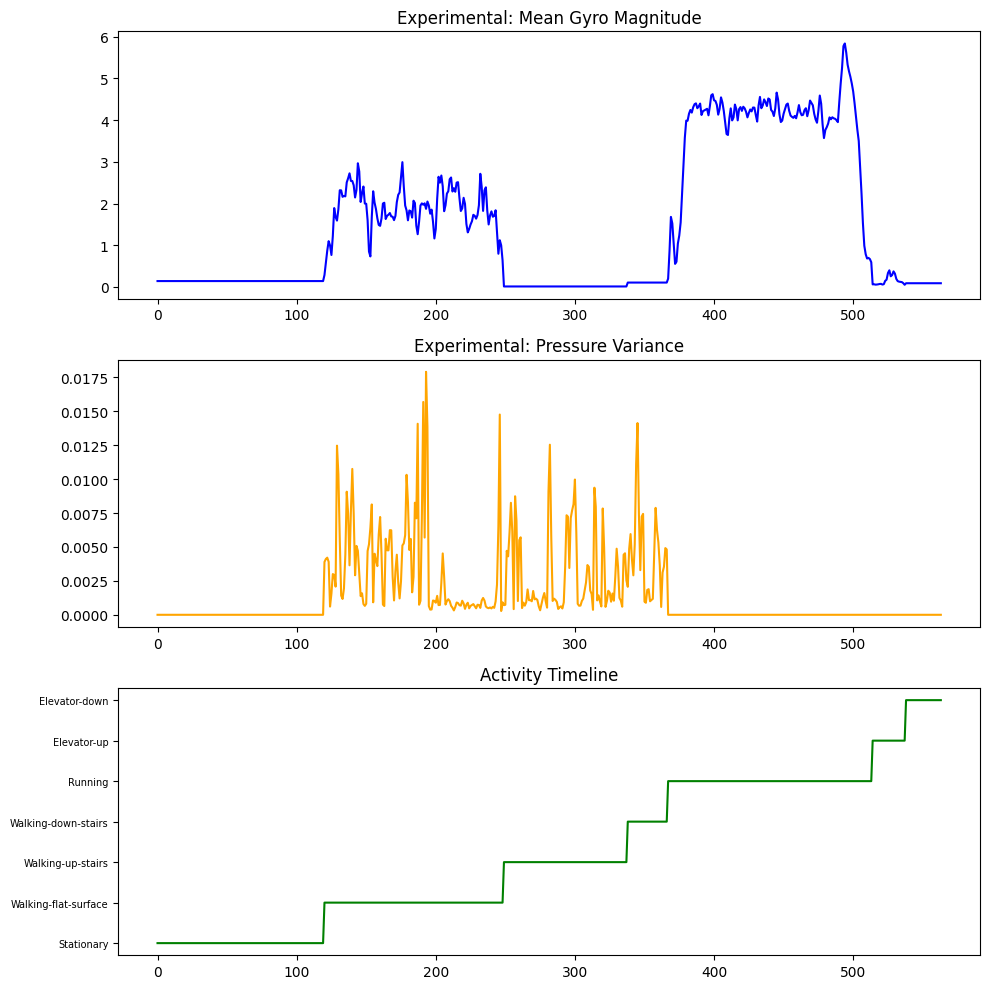

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- 1. Activity Mapping (Match these to your filenames) ---
activity_indices = {
    'Stationary': 0, 
    'Walking-flat-surface': 1, 
    'Walking-up-stairs': 2,
    'Walking-down-stairs': 3, 
    'Running': 4, 
    'Elevator-up': 5, 
    'Elevator-down': 6
}

def get_sensor_file(path, activity, sensor):
    """Finds files like mnh25cyu_Stationary_accel.txt"""
    files = os.listdir(path)
    for f in files:
        if activity in f and sensor in f and f.endswith('.txt'):
            return os.path.join(path, f)
    return None

def compute_raw_data_robust(path, activity):
    accel_path = get_sensor_file(path, activity, 'accel')
    gyro_path = get_sensor_file(path, activity, 'gyro')
    pressure_path = get_sensor_file(path, activity, 'pressure')

    if not accel_path:
        print(f"  [SKIP] {activity}: Missing Accelerometer.")
        return None, None

    # Use Accelerometer to define the timeframe
    accel_raw = pd.read_csv(accel_path, sep=",", names=['time', 'x', 'y', 'z'])
    
    t_min = accel_raw['time'].min()
    t_max = accel_raw['time'].max()
    total_duration = t_max - t_min
    is_ms = total_duration > 1000
    
    # 0.5 second trim is enough
    trim = 500 if is_ms else 0.5
    step = 20 if is_ms else 0.02
    
    t_start = t_min + trim
    t_end = t_max - trim
    
    if t_end <= t_start:
        print(f"  [SKIP] {activity}: Duration too short.")
        return None, None

    timestamps = np.arange(t_start, t_end, step) 

    # Interpolate Accel
    ax = np.interp(timestamps, accel_raw['time'], accel_raw['x'])
    ay = np.interp(timestamps, accel_raw['time'], accel_raw['y'])
    az = np.interp(timestamps, accel_raw['time'], accel_raw['z'])
    accel_mag = np.sqrt(ax**2 + ay**2 + az**2)

    # Interpolate Gyro (if missing, use zeros)
    if gyro_path:
        gyro_raw = pd.read_csv(gyro_path, sep=",", names=['time', 'gx', 'gy', 'gz'])
        gx = np.interp(timestamps, gyro_raw['time'], gyro_raw['gx'])
        gy = np.interp(timestamps, gyro_raw['time'], gyro_raw['gy'])
        gz = np.interp(timestamps, gyro_raw['time'], gyro_raw['gz'])
        gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)
    else:
        gyro_mag = np.zeros(len(timestamps))

    # Interpolate Pressure (if missing, use constant)
    if pressure_path:
        pressure_raw = pd.read_csv(pressure_path, sep=",", names=['time', 'p'])
        p = np.interp(timestamps, pressure_raw['time'], pressure_raw['p'])
    else:
        p = np.full(len(timestamps), 1013.25)

    labels = np.full(len(timestamps), activity_indices[activity])
    return np.stack((accel_mag, p, gyro_mag), axis=1), labels

def feature_extraction(raw_data, raw_labels):
    window_size, step_size = 100, 50 
    feat_list, lab_list = [], []
    
    for i in range(0, len(raw_data) - window_size, step_size):
        win = raw_data[i : i + window_size]
        
        # Experimental Features
        m_gyro = np.mean(win[:, 2])      # Feature 3
        v_pressure = np.var(win[:, 1])  # Feature 4
        
        m_acc = np.mean(win[:, 0])
        v_acc = np.var(win[:, 0])
        slope_p = np.polyfit(np.arange(window_size), win[:, 1], 1)[0]
        max_fft = np.max(np.abs(np.fft.fft(win[:, 0]))[1:50])

        feat_list.append([m_acc, v_acc, slope_p, m_gyro, v_pressure, max_fft])
        lab_list.append(Counter(raw_labels[i : i + window_size]).most_common(1)[0][0])
    
    return np.array(feat_list), np.array(lab_list)

# --- EXECUTION ---
data_path = './A3_Data/mnh25cyu' 
all_feat, all_lab = [], []

for act in activity_indices.keys():
    raw_d, raw_l = compute_raw_data_robust(data_path, act)
    if raw_d is not None:
        f, l = feature_extraction(raw_d, raw_l)
        if f.size > 0:
            print(f"  [SUCCESS] {act}: {len(f)} windows.")
            all_feat.append(f)
            all_lab.append(l)

if all_feat:
    features = np.vstack(all_feat)
    labels = np.concatenate(all_lab)

    # --- PLOT ---
    plt.figure(figsize=(10, 10))
    plt.subplot(3,1,1); plt.plot(features[:, 3], color='blue'); plt.title('Experimental: Mean Gyro Magnitude')
    plt.subplot(3,1,2); plt.plot(features[:, 4], color='orange'); plt.title('Experimental: Pressure Variance')
    plt.subplot(3,1,3); plt.plot(labels, color='green'); plt.title('Activity Timeline')
    plt.yticks(range(7), activity_indices.keys(), fontsize=7)
    plt.tight_layout(); plt.show()

In [25]:
# Check how many windows we have per activity
for i, activity_name in enumerate(activity_indices.keys()):
    # Count how many times this label appears in our final 'labels' array
    count = np.sum(labels == activity_indices[activity_name])
    print(f"{activity_name}: {count} windows found")

Stationary: 0 windows found
Walking-flat-surface: 126 windows found
Walking-up-stairs: 0 windows found
Walking-down-stairs: 0 windows found
Running: 0 windows found
Elevator-up: 0 windows found
Elevator-down: 0 windows found


In [32]:
def five_fold_cross_validation(features, labels):

  true_labels = list()
  predicted_labels = list()

  for train_index, test_index in StratifiedKFold(n_splits=5).split(features, labels):
    X_train = features[train_index, :]
    Y_train = labels[train_index]

    X_test = features[test_index, :]
    Y_test = labels[test_index]

    clf = DecisionTreeClassifier()
    clf.fit(X_train, Y_train)
    predicted_label = clf.predict(X_test)

    predicted_labels += predicted_label.flatten().tolist()
    true_labels += Y_test.flatten().tolist()

  # Given N different activities, the confusion matrix is a N*N matrix
  confusion_matrix = np.zeros((len(activity_indices), len(activity_indices)))

  for i in range(len(true_labels)):
    confusion_matrix[int(true_labels[i]), int(predicted_labels[i])] += 1

  # Normalized confusion matrix
  #for i in range(confusion_matrix.shape[0]):
   # print(sum(confusion_matrix[i, :]))
   #  confusion_matrix[i, :] = confusion_matrix[i, :]/sum(confusion_matrix[i, :])

  print("===== Confusion Matrix (within subject) =====")
  plot_confusion_matrix(confusion_matrix, activity_indices.keys(), normalize=False)
  plt.show()

In [8]:
def evaluate_generalized_model(X_train, Y_train, X_test, Y_test):
  clf = DecisionTreeClassifier().fit(X_train, Y_train)
  Y_pred = clf.predict(X_test)

  # # Plot the true labels and predicted labels
  # plt.subplot(2, 1, 1)
  # plt.plot(Y_test)
  #
  # plt.subplot(2, 1, 2)
  # plt.plot(Y_pred)
  #
  # plt.show()

  # Given N activities, the confusion matrix is a N*N matrix
  confusion_matrix = np.zeros((len(activity_indices), len(activity_indices)))

  for i in range(len(Y_test)):
    confusion_matrix[int(Y_test[i]), int(Y_pred[i])] += 1

  # print(confusion_matrix)

  # for i in range(confusion_matrix.shape[0]):
  #   # print(sum(confusion_matrix[i, :]))
  #   confusion_matrix[i, :] = confusion_matrix[i, :]/sum(confusion_matrix[i, :])

  print("===== Confusion Matrix (between subjects) =====")
  # plt.imshow(confusion_matrix)
  # plt.show()
  plot_confusion_matrix(confusion_matrix, activity_indices.keys())
  plt.show()

  # Print the top-5 features
  #selector = RFE(clf, 5)
  selector = RFE(clf, n_features_to_select=5, step=1)
  selector.fit(X_train, Y_train)
  print("===== Mask of Top-5 Features =====")
  print(selector.support_)

In [9]:
def plot_confusion_matrix(confusion_matrix, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """ This function prints and plots the confusion matrix.
        Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        confusion_matrix = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(confusion_matrix)

    plt.imshow(confusion_matrix, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else '.0f'
    thresh = confusion_matrix.max() / 2.
    for i, j in itertools.product(range(confusion_matrix.shape[0]), range(confusion_matrix.shape[1])):
        plt.text(j, i, format(confusion_matrix[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if confusion_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/mnh25cyu


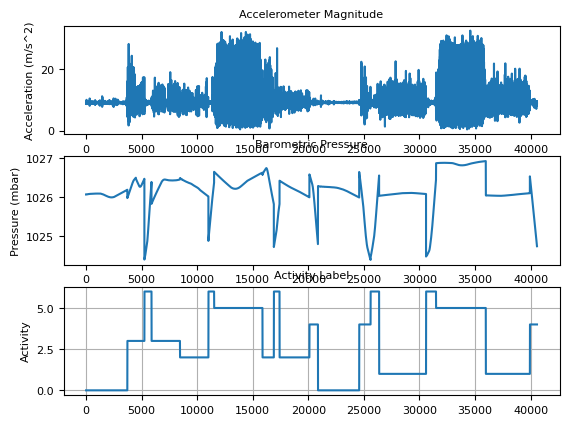

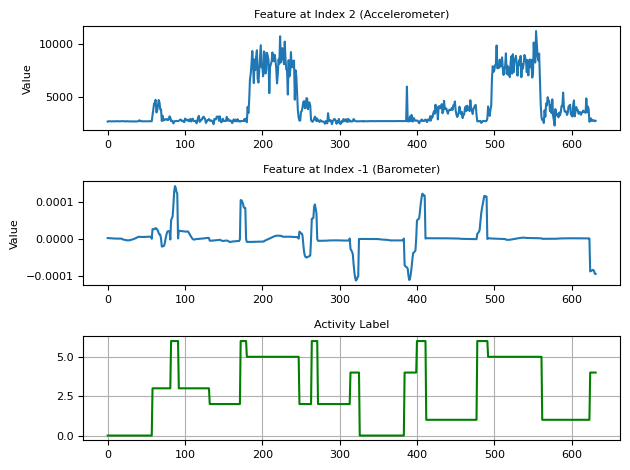

===== Confusion Matrix (within subject) =====
Confusion matrix, without normalization
[[ 91.   0.  15.   4.   1.   1.   4.]
 [  0.  99.   1.   8.   0.  14.   6.]
 [  0.   0.  72.   9.   7.   8.   2.]
 [  2.   5.  14.  27.   7.   3.   6.]
 [  2.   1.   2.   6.  23.   2.   0.]
 [  0.   7.   2.   1.   0. 127.   1.]
 [  7.   1.   1.   4.   1.   0.  38.]]


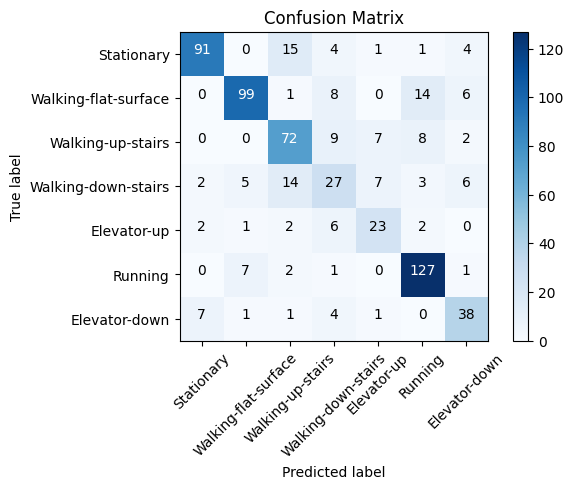

Processing data from ahs264
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/ahs264
Processing data from cyt25
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/cyt25
Processing data from xl549
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/xl549
Processing data from xz278
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/xz278


/Users/sudiptogoldfish/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sudiptogoldfish/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing data from aks249
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/aks249
Processing data from mmb289
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/mmb289
Processing data from nk428
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/nk428
Processing data from mlc299
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/mlc299
Processing data from mnh25cyu
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/mnh25cyu
Processing data from bl4521
Processing data from directory: /Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/bl4521


/Users/sudiptogoldfish/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sudiptogoldfish/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(2994, 14) (2994,) (632, 14) (632,)
===== Confusion Matrix (between subjects) =====
Confusion matrix, without normalization
[[ 59.  18.   1.   0.  34.   0.   4.]
 [  3. 113.   7.   2.   0.   3.   0.]
 [ 21.  19.   2.   3.  49.   0.   4.]
 [  5.  18.   3.  29.   6.   0.   3.]
 [  1.   0.   2.   0.  32.   0.   1.]
 [  0.  42.   0.   0.   3.  93.   0.]
 [  1.   3.   0.   6.   0.   0.  42.]]


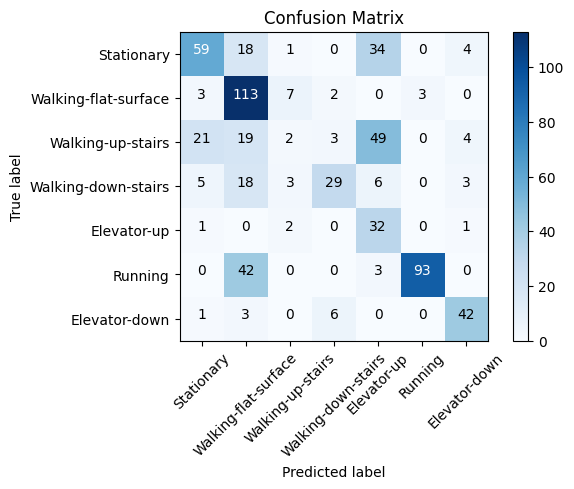

===== Mask of Top-5 Features =====
[ True  True False  True False False False False False False False False
  True  True]


In [42]:
if __name__ == "__main__":

  data_path = '/Users/sudiptogoldfish/code files/7040B UC Lab/WEEK 5 and 6/Reserve_A3_Data/'
  # Change it to your net id
  my_netid = 'mnh25cyu' # --- IGNORE ---

  raw_data_features, raw_data_labels, timestamps = compute_raw_data(data_path + my_netid)


  "***Plot Raw Data***"
  # Plot the raw data to get a sense about what features might work.
  # You can comment out this line of code if you don't want to see the plots
  plot_raw_data(raw_data_features, raw_data_labels)


  "***Feature Extraction***"
  features, labels = feature_extraction(raw_data_features, raw_data_labels, timestamps)


  "***Plot Features***"
  # You can comment out this line of code if you don't want to see the plots
  plot_extracted_features(features, labels)


  "***Classify User's Own Data***"
  five_fold_cross_validation(features, labels)


  "***Person-independent model (i.e. train on other's data and test on your own data)***"
  X_train = None
  Y_train = None
  X_test = None
  Y_test = None

  dirs = os.listdir(data_path)
  for dir in dirs:
    print("Processing data from %s" %dir)
    raw_data_features, raw_data_labels, timestamps = compute_raw_data(data_path + dir)
    features, labels = feature_extraction(raw_data_features, raw_data_labels, timestamps)

    if dir == my_netid:
      X_test = features
      Y_test = labels

    else:
      if X_train is None:
        X_train = features
        Y_train = labels
      else:
        X_train = np.append(X_train, features, axis=0)
        Y_train = np.append(Y_train, labels, axis=0)

  print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)
  evaluate_generalized_model(X_train, Y_train, X_test, Y_test)